Take in microsphere camera and confocal images and their pixel probabilities, extract centroid coordinates from adequate signals, match between detectors, and calculate the corresponding affine transformation.

In [1]:
from skimage import io,measure,transform,util,feature
from skimage.transform import warp
from skimage.measure import ransac
import numpy as np
import pandas as pd

In [2]:
# If don't have coords but have pixel probability images. 

# camera_prob_path=r'C:\Users\jglic\OneDrive - Washington University in St. Louis\Documents\School\WashU\Mukherji Lab\Experiment Images\affine-transf-coords\11-2-25 110 nm beads\TRITC_512_110nm-beads_fov1-sub_Probabilities.tiff'
# camera_bkgd=io.imread(camera_prob_path)
# camera_bead=1-camera_bkgd
# camera_mask=measure.label(transform.rotate(camera_bead>camera_bkgd, 90)) #rotate now since will do before applying transform later.
# camera_metrics=measure.regionprops_table(camera_mask,properties=('label','centroid','eccentricity'))

# laser_prob_path=r'C:\Users\jglic\OneDrive - Washington University in St. Louis\Documents\School\WashU\Mukherji Lab\Experiment Images\affine-transf-coords\11-2-25 110 nm beads\red-confocal_110nm-512_110nm-beads_fov1-sub_Probabilities.tiff'
# laser_bkgd=io.imread(laser_prob_path)
# laser_bead=1-laser_bkgd
# laser_mask=measure.label(laser_bead>laser_bkgd)
# laser_metrics=measure.regionprops_table(laser_mask,properties=('label','centroid','eccentricity'))

# #extracting the XY centroid coords of objects with an eccentricity below set threshold.
# #recall that ecc=0 is a circle and ecc=1 is a parabola.
# ecc_threshold=.6
# camera_centroids=np.array([(camera_metrics['centroid-0'][i],camera_metrics['centroid-1'][i]) for i in range(len(camera_metrics['eccentricity'])) if camera_metrics['eccentricity'][i]<=ecc_threshold])
# laser_centroids=np.array([(laser_metrics['centroid-0'][i],laser_metrics['centroid-1'][i]) for i in range(len(laser_metrics['eccentricity'])) if laser_metrics['eccentricity'][i]<=ecc_threshold])
# len(camera_centroids), len(laser_centroids)
# matches=feature.match_descriptors(camera_centroids,laser_centroids, max_ratio=0.8)
# len(matches)

# camera_coords=[]
# laser_coords=[]
# for i in range(len(matches)):
#     camera_coords.append(camera_centroids[matches[i][0]])
#     laser_coords.append(laser_centroids[matches[i][1]])
# camera_coords=np.array(camera_coords)
# laser_coords=np.array(laser_coords)

# transf_affine=transform.estimate_transform('affine', src=camera_coords, dst=laser_coords)

In [ ]:
# # If already have unmatched coords, such as from auto maxima find in ImageJ.

camera_maxima=pd.read_csv(r'C:\Users\jglic\OneDrive - Washington University in St. Louis\Documents\School\WashU\Mukherji Lab\Experiment Images\affine-transf-coords\11-7-25 2048_400nm\manual-max-coords_camera_512_fov1_GB-rad=2.csv')
laser_maxima = pd.read_csv(r'C:\Users\jglic\OneDrive - Washington University in St. Louis\Documents\School\WashU\Mukherji Lab\Experiment Images\affine-transf-coords\11-7-25 2048_400nm\manual-max-coords_laser_512_fov1_GB-rad=2.csv')
#extract the XY coords as ordered arrays of tuples. 
camera_coords=np.array([(camera_maxima['X'][i],camera_maxima['Y'][i]) for i in range(len(camera_maxima))]) ## (X,Y) OR (Y,X) ??????
laser_coords=np.array([(laser_maxima['X'][i],laser_maxima['Y'][i]) for i in range(len(laser_maxima))])

# ## If not already matched between images.
# matches=feature.match_descriptors(camera_coords,laser_coords,cross_check=True,max_ratio=0.8) #brute force matches between images.
# camera_matches=[]
# laser_matches=[]
# for i in range(len(matches)):
#     camera_matches.append(camera_coords[matches[i][0]])
#     laser_matches.append(laser_coords[matches[i][1]])
# camera_matches=np.array(camera_matches)
# laser_matches=np.array(laser_matches)

# model_robust, inliers = ransac((camera_matches, laser_matches),transform.AffineTransform,min_samples=11,
#     residual_threshold=2)

# transf_affine=transform.estimate_transform('affine', src=camera_matches, dst=laser_matches)
transf_affine=transform.estimate_transform('affine', src=camera_coords, dst=laser_coords)


In [3]:
print("Affine transform:")
print(
    f'Scale: ({transf_affine.scale[0]:.4f}, {transf_affine.scale[1]:.4f}), '
    f'Translation: ({transf_affine.translation[0]:.4f}, '
    f'{transf_affine.translation[1]:.4f}), '
    f'Rotation: {transf_affine.rotation:.4f}')
    
# print("RANSAC:")
# print(
#     f'Scale: ({model_robust.scale[0]:.4f}, {model_robust.scale[1]:.4f}), '
#     f'Translation: ({model_robust.translation[0]:.4f}, '
#     f'{model_robust.translation[1]:.4f}), '
#     f'Rotation: {model_robust.rotation:.4f}')

Affine transform:
Scale: (1.0617, 1.0580), Translation: (-35.7873, 0.4920), Rotation: -0.0431


Number of matches: 5


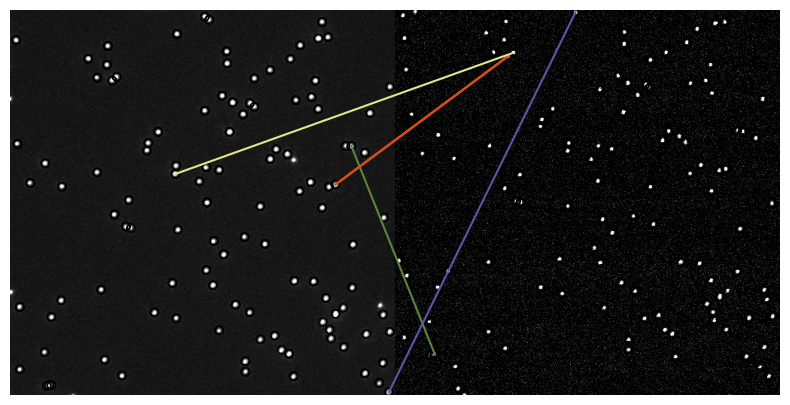

In [ ]:
## Code that applies sift and RANSAC to detect, match, and refine descriptors.

# from skimage import io, color, feature
# import numpy as np
# import matplotlib.pyplot as plt

# # # Load images (convert to grayscale)
# img_camera = color.rgb2gray(io.imread(r'C:\Users\jglic\OneDrive - Washington University in St. Louis\Documents\School\WashU\Mukherji Lab\Experiment Images\affine-transf-coords\11-2-25 110 nm beads\TRITC_512_110nm-beads_fov1-sub_rot90ccw.png'))
# img_laser = color.rgb2gray(io.imread(r'C:\Users\jglic\OneDrive - Washington University in St. Louis\Documents\School\WashU\Mukherji Lab\Experiment Images\affine-transf-coords\11-2-25 110 nm beads\red-confocal_110nm-512_110nm-beads_fov1-sub.png'))
# # img_camera = io.imread(r'C:\Users\jglic\OneDrive - Washington University in St. Louis\Documents\School\WashU\Mukherji Lab\Experiment Images\affine-transf-coords\11-4-25 ey-rbow-acquisition-testing\confgreenjg_512_fov2.tif')
# # img_laser = io.imread(r'C:\Users\jglic\OneDrive - Washington University in St. Louis\Documents\School\WashU\Mukherji Lab\Experiment Images\affine-transf-coords\11-4-25 ey-rbow-acquisition-testing\FITC_512_eyrbow_fov2.tif')

# # Initialize SIFT detector
# sift = feature.SIFT()

# # Detect and extract features from both images
# sift.detect_and_extract(img_camera)
# keypoints1 = sift.keypoints
# descriptors1 = sift.descriptors

# sift.detect_and_extract(img_laser)
# keypoints2 = sift.keypoints
# descriptors2 = sift.descriptors

# # Match the descriptors between the two images
# from skimage.feature import match_descriptors
# matches = match_descriptors(descriptors1, descriptors2,cross_check=True,max_ratio=0.6)

# print(f"Number of matches: {len(matches)}")
# from skimage.feature import plot_matches

# fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# plot_matches(ax, img_camera, img_laser, keypoints1, keypoints2, matches)
# ax.axis('off')
# plt.show()
# from skimage import transform

# # Get matched coordinates
# src = keypoints1[matches[:, 0]]
# dst = keypoints2[matches[:, 1]]

# from skimage.measure import ransac
# model_robust, inliers = ransac((src, dst),transform.AffineTransform,min_samples=4,
#     residual_threshold=2,max_trials=1000)
# from skimage.transform import warp

# warped_img = warp(img_camera, inverse_map=model_robust.inverse, output_shape=img_laser.shape)
# plt.imshow(warped_img, cmap='gray')
# plt.title("Warped Camera to align with Confocal")
# plt.show()

In [ ]:
## Rescale 2048 image to 512 prior to choosing coords for calculating affine transform.
# path_2048=r'C:\Users\jglic\Downloads\10-22-25 live imaging ref spectra\BF_sec61_fov1.tif'
# def rescale_2048(path):
#     img_2048=io.imread(str(path))
#     img_downsc=transform.rescale(img_2048,0.25, anti_aliasing=True)
#     # print(np.shape(img_downsc))
#     # img_out = np.zeros((512,512),dtype=int) # hard coded size, bad.   Stuff to correct (2048,2044); idk figure it out later.
#     # shape0,shape1,shape2 = img_downsc.shape
#     # img_out[:shape0,:shape1,0] = img_downsc
#     io.imsave(path[0:-4]+'_downscaled.tif',util.img_as_float32(img_downsc)) #save edited image as new file with updated name.
#     print("Rescaled image saved as: "+path[0:-4]+'_downscaled.tif')
# rescale_2048(path_2048)

Rescaled image saved as: C:\Users\jglic\Downloads\10-22-25 live imaging ref spectra\BF_sec61_fov1_downscaled.tif


C:\Users\jglic\AppData\Local\Temp\ipykernel_11848\2210668646.py:10: UserWarning: C:\Users\jglic\Downloads\10-22-25 live imaging ref spectra\BF_sec61_fov1_downscaled.tif is a low contrast image
  io.imsave(path[0:-4]+'_downscaled.tif',util.img_as_float32(img_downsc)) #save edited image as new file with updated name.


Testing the transform

In [ ]:
preprocesses = [
    lambda x: transform.rotate(x,90),
    lambda x: transform.rescale(x,0.25, anti_aliasing=True),
    lambda x: transform.warp(x,transf_affine.inverse)]
    # lambda x: (x-x.min())/(x.max()-x.min())] #rescaling image; outputs pixel values between [0,1] corresponding to [min, max].

In [5]:
# path_in=r'C:\Users\jglic\OneDrive - Washington University in St. Louis\Documents\School\WashU\Mukherji Lab\Experiment Images\affine-transf-coords\11-2-25 110 nm beads\TRITC_1024_110nm-beads_fov1.tif'
path_in=r'C:\Users\jglic\OneDrive - Washington University in St. Louis\Documents\School\WashU\Mukherji Lab\Experiment Images\affine-transf-coords\11-7-25 2048_400nm\FITC_2048_fov1.tif'
img_in=io.imread(str(path_in)) #load in bright-field time series.
if len(img_in.shape)==2: #for time-snapshot (2D) camera images.
    print('>>>>>>>>>>>>>>>>>>Processing time snapshot.<<<<<<<<<<<<<<<<<<<')
    for prep in preprocesses:
        img_in=prep(img_in)
    img_out=img_in #quick fix
elif len(img_in.shape)==3: #for time series camera captures.
    print('>>>>>>>>>>>>>>>>>Processing time series.<<<<<<<<<<<<<<<<<<<<')
    img_out=[] #initalize empty list to append processed slices to.
    for i in range(img_in.shape[0]): #for each time point in series
        img_dummy=img_in[i,:,:] #create dummy array to perform operations and maintain changes. 
        for prep in preprocesses: #apply the affine transform and pixel scaling to confocal captures. 
            img_dummy = prep(img_dummy) #update each time slice of image array as transforms are applied.
        img_out.append(img_dummy)
    img_out=np.asarray(img_out) #turn nested list into 3D array.
else:
    print('>>>>>>>>>>>>>>>>>>Outside scope of current code. Please update.<<<<<<<<<<<<<<<<<<') 

io.imsave(path_in[0:-4]+'_afftransf.tif',util.img_as_float32(img_out)) #save edited image as new file with updated name.

>>>>>>>>>>>>>>>>>>Processing time snapshot.<<<<<<<<<<<<<<<<<<<


C:\Users\jglic\AppData\Local\Temp\ipykernel_11848\3277913097.py:21: UserWarning: C:\Users\jglic\OneDrive - Washington University in St. Louis\Documents\School\WashU\Mukherji Lab\Experiment Images\affine-transf-coords\11-7-25 2048_400nm\FITC_2048_fov1_afftransf.tif is a low contrast image
  io.imsave(path_in[0:-4]+'_afftransf.tif',util.img_as_float32(img_out)) #save edited image as new file with updated name.


In [ ]:
# ransac_img= warp(img_in, inverse_map=model_robust.inverse, output_shape=(512,512))
# io.imsave(path_in[0:-4]+'_ransac.tif',util.img_as_float32(ransac_img)) #save edited image as new file with updated name.

C:\Users\jglic\AppData\Local\Temp\ipykernel_5628\4178183246.py:3: UserWarning: C:\Users\jglic\OneDrive - Washington University in St. Louis\Documents\School\WashU\Mukherji Lab\Experiment Images\affine-transf-coords\11-7-25 2048_400nm\TRITC_2048_fov3_ransac.tif is a low contrast image
  io.imsave(path_in[0:-4]+'_ransac.tif',util.img_as_float32(ransac_img)) #save edited image as new file with updated name.
